CI Bus Routing Experimentation - Gamma Experimentation

Part 1: Set Up Codespace

In [1]:
import gymnasium as gym
import os
import torch
import torch.nn as nn
import numpy as np
from random import sample
from gymnasium import spaces
from collections import deque
from matplotlib import pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

I0000 00:00:1777122317.801309 1764363 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Check for GPU availability (CUDA first, then MPS, then CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


/home/users/jfr29/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Part 2: Custom Gymnasium Environment

In [3]:
class BusEnv(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 4}

    def __init__(self, config=None, render_mode=None):
        super().__init__()

        config = config or {}

        # Route / simulation settings
        self.num_stops = config.get("num_stops", 14)
        self.max_buses = config.get("max_buses", 6)
        self.bus_capacity = config.get("bus_capacity", 100)
        self.episode_length = config.get("episode_length", 960)  # 8:00am to 12:00am, 1 step = 1 minute
        self.max_queue = config.get("max_queue", 500)

        self.base_arrival_rates = np.array(
            config.get(
                "base_arrival_rates",
                [30, 2, 2, 2, 2, 2, 2, 40, 4, 2, 2, 2, 2, 2],
            ),
            dtype=np.float32,
        )

        # Reward weights
        self.pickup_reward = config.get("pickup_reward", 0.1)
        self.left_behind_penalty = config.get("left_behind_penalty", 0.001)
        self.waiting_penalty = config.get("waiting_penalty", 0.00001)
        self.active_bus_penalty = config.get("active_bus_penalty", 0.1)

        self.render_mode = render_mode
        assert render_mode is None or render_mode in self.metadata["render_modes"]

        # Bus features per bus:
        # stop, occupancy, active, held, segment
        self.bus_features = 5

        # Observation:
        # [timestep, active_bus_count]
        # + queue lengths for each stop
        # + time since last service for each stop
        # + bus states for each possible bus
        obs_size = (
            2 + self.num_stops + self.num_stops + self.max_buses * self.bus_features
        )
        self.observation_space = spaces.Box(
            low=0.0,
            high=1000.0,
            shape=(obs_size,),
            dtype=np.float32,
        )

        # 0 = normal operation
        # 1 = add a bus
        # 2 = remove a bus
        # 3 = hold a bus
        self.action_space = spaces.Discrete(4)

        self.window = None
        self.clock = None

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.timestep = 0

        # Queue at each stop
        self.queues = np.zeros(self.num_stops, dtype=np.int32)

        # How many steps since each stop was last served
        self.last_service = np.zeros(self.num_stops, dtype=np.int32)

        # Bus states
        self.buses = []
        for _ in range(self.max_buses):
            self.buses.append(
                {
                    "stop": 0,
                    "occupancy": 0,
                    "active": 0,
                    "held": 0,
                }
            )

        # Start with one active bus at stop 0
        self.buses[0]["active"] = 1
        self.buses[0]["stop"] = 0
        self.buses[0]["occupancy"] = 0
        self.buses[0]["held"] = 0

        obs = self._get_obs()
        info = self._get_info()

        return obs, info

    def step(self, action):
        self.timestep += 1

        self._generate_passengers()
        self._apply_action(action)
        picked_up, left_behind = self._move_buses_and_board()

        # Increase time since last service for all stops,
        # then reset happens inside boarding when a stop is served
        self.last_service += 1

        total_waiting = int(np.sum(self.queues))
        active_buses = self._active_bus_count()

        reward = (
            self.pickup_reward * picked_up
            - self.left_behind_penalty * left_behind
            - self.waiting_penalty * total_waiting
            - self.active_bus_penalty * active_buses
        )

        terminated = self.timestep >= self.episode_length
        truncated = False

        obs = self._get_obs()
        info = self._get_info()
        info.update(
            {
                "picked_up": picked_up,
                "left_behind": left_behind,
                "reward": reward,
            }
        )

        if self.render_mode == "human":
            self.render()

        return obs, reward, terminated, truncated, info

    def render(self):
        print(f"\nTime step: {self.timestep}")
        print(f"Queues: {self.queues.tolist()}")
        for i, bus in enumerate(self.buses):
            if bus["active"]:
                print(
                    f"Bus {i}: stop={bus['stop']}, "
                    f"segment={'WB' if self.is_westbound_stop(bus['stop']) else 'EB'}, "
                    f"occupancy={bus['occupancy']}, held={bus['held']}"
                )

    def close(self):
        pass

    def _get_obs(self):
        obs = [self.timestep, self._active_bus_count()]

        # stop queues
        obs.extend(self.queues.tolist())

        # time since last service
        obs.extend(self.last_service.tolist())

        # per-bus features
        for bus in self.buses:
            segment = 0 if self.is_westbound_stop(bus["stop"]) else 1
            obs.extend(
                [
                    bus["stop"],
                    bus["occupancy"],
                    bus["active"],
                    bus["held"],
                    segment,
                ]
            )

        return np.array(obs, dtype=np.float32)

    def _get_info(self):
        return {
            "timestep": self.timestep,
            "active_buses": self._active_bus_count(),
            "total_waiting": int(np.sum(self.queues)),
        }

    def _generate_passengers(self):
        arrivals = self.np_random.poisson(self.base_arrival_rates).astype(np.int32)

        # 9:00am class spike
        # If 8:00 = step 0, then 9:00 = step 60
        if 55 <= self.timestep <= 70:
            arrivals[0] += self.np_random.poisson(150)  # East campus terminal spike

        # 11:30am spike
        if 205 <= self.timestep <= 220:
            arrivals[7] += self.np_random.poisson(150)  # West campus terminal spike

        self.queues = np.minimum(self.queues + arrivals, self.max_queue)

    def _apply_action(self, action):
        if action == 1:
            self._add_bus()
        elif action == 2:
            self._remove_bus()
        elif action == 3:
            self._hold_bus()
        # action == 0 means normal operation

    def _add_bus(self):
        inactive_indices = [i for i, b in enumerate(self.buses) if b["active"] == 0]
        if not inactive_indices:
            return

        # Place new bus at busiest stop
        busiest_stop = int(np.argmax(self.queues))
        idx = inactive_indices[0]

        self.buses[idx]["active"] = 1
        self.buses[idx]["stop"] = busiest_stop
        self.buses[idx]["occupancy"] = 0
        self.buses[idx]["held"] = 0

    def _remove_bus(self):
        active_indices = [i for i, b in enumerate(self.buses) if b["active"] == 1]

        # Keep at least one bus active
        if len(active_indices) <= 1:
            return

        # Remove emptiest active bus
        remove_idx = min(active_indices, key=lambda i: self.buses[i]["occupancy"])

        self.buses[remove_idx]["active"] = 0
        self.buses[remove_idx]["occupancy"] = 0
        self.buses[remove_idx]["held"] = 0

    def _hold_bus(self):
        active_indices = [i for i, b in enumerate(self.buses) if b["active"] == 1]
        if not active_indices:
            return

        # Hold the bus closest to the busiest stop
        busiest_stop = int(np.argmax(self.queues))

        def loop_distance(a, b):
            forward = (b - a) % self.num_stops
            backward = (a - b) % self.num_stops
            return min(forward, backward)

        hold_idx = min(
            active_indices,
            key=lambda i: loop_distance(self.buses[i]["stop"], busiest_stop),
        )
        self.buses[hold_idx]["held"] = 1

    def _move_buses_and_board(self):
        total_picked_up = 0
        total_left_behind = 0

        for bus in self.buses:
            if bus["active"] == 0:
                continue

            # Move unless held
            if bus["held"] == 1:
                bus["held"] = 0
            else:
                bus["stop"] = self.next_stop(bus["stop"])

            stop = bus["stop"]

            # Board passengers
            waiting = int(self.queues[stop])
            available_space = self.bus_capacity - bus["occupancy"]

            boarded = min(waiting, available_space)
            left_behind = max(0, waiting - available_space)

            bus["occupancy"] += boarded
            self.queues[stop] -= boarded
            self.last_service[stop] = 0

            total_picked_up += boarded
            total_left_behind += left_behind

            # Simple drop-off rule:
            if stop == 0 or stop == 7:
                dropped = bus["occupancy"]  # All off at terminals
            else:
                dropped = int(
                    0.01 * bus["occupancy"]
                )  # some fraction of riders leave at each stop
            bus["occupancy"] -= dropped

        return total_picked_up, total_left_behind

    def next_stop(self, stop):
        return (stop + 1) % self.num_stops

    def is_westbound_stop(self, stop):
        return 0 <= stop <= 7

    def is_eastbound_stop(self, stop):
        return 8 <= stop <= 13

    def _active_bus_count(self):
        return sum(bus["active"] for bus in self.buses)

Part 3: Training Loop

In [4]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/BusRouting-v0",
    entry_point=BusEnv,
    max_episode_steps=50000,  # Prevent infinite episodes
)

gam = [0.95, 0.99, 0.9999]
envs = []

for g in gam:
    
    # Create the environment like any built-in environment
    env = gym.make("gymnasium_env/BusRouting-v0")
    env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=1000)
    env = Monitor(env)

    # Can adjust training hyperparameters of agent as needed
    model = PPO(
        policy="MlpPolicy",
        env=env,
        verbose=0,
        learning_rate=0.001,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=g,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.0
    )
    
    # Train the model
    model.learn(total_timesteps=100_000)
    
    envs.append(env)
    
    print(f"\nTraining of Agent complete!")

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 960      |
|    ep_rew_mean     | 4.04e+03 |
| time/              |          |
|    fps             | 1040     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
--------------------------------------
| rollout/                |          |
|    ep_len_mean          | 960      |
|    ep_rew_mean          | 4.75e+03 |
| time/                   |          |
|    fps                  | 538      |
|    iterations           | 2        |
|    time_elapsed         | 7        |
|    total_timesteps      | 4096     |
| train/                  |          |
|    approx_kl            | 0.018975 |
|    clip_fraction        | 0.314    |
|    clip_range           | 0.2      |
|    entropy_loss         | -1.37    |
|    explained_variance   | 0.00129  |
|    learning_rate     

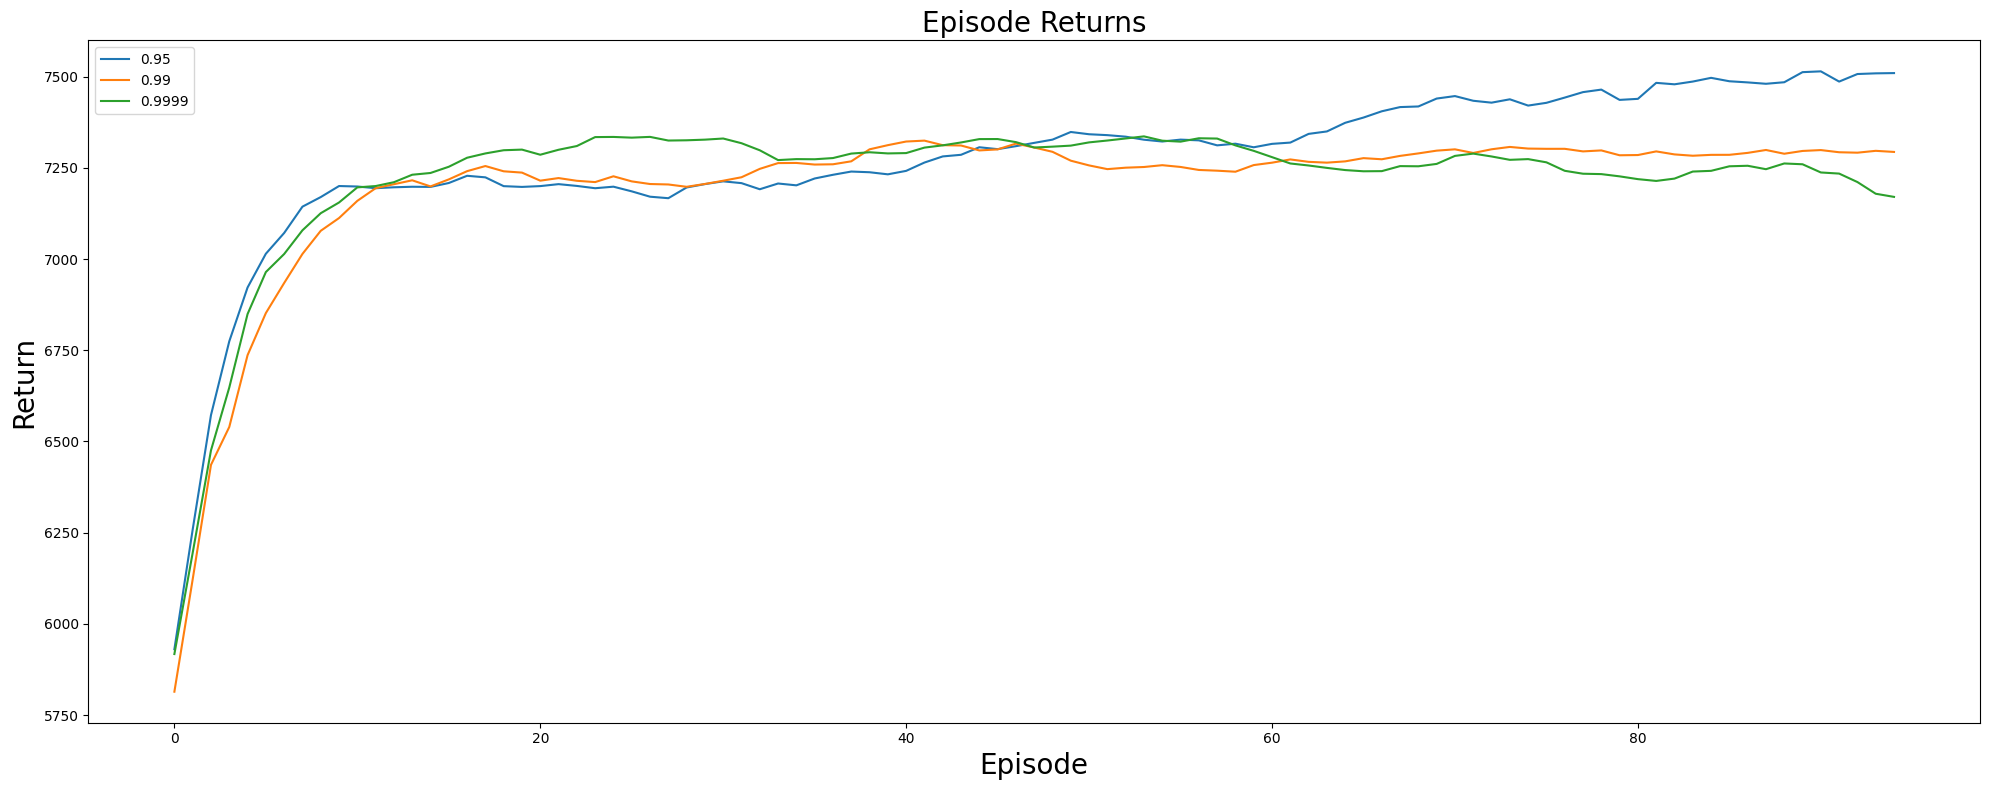

In [7]:
def _get_returns_from_env(env):
    if hasattr(env, "return_queue"):
        return np.array(env.return_queue)

    inner_env = getattr(env, "env", None)
    if inner_env is not None and hasattr(inner_env, "return_queue"):
        return np.array(inner_env.return_queue)

    if hasattr(env, "get_episode_rewards"):
        return np.array(env.get_episode_rewards())

    raise AttributeError(
        "Environment does not expose episode returns. "
        "Wrap the env with RecordEpisodeStatistics or Monitor."
    )


def visualize_learning_curves(envs, smoothing=10, labels=None):
    fig, ax = plt.subplots(1, 1, figsize=(20, 8))

    if labels is None:
        labels = [f"Run {i}" for i in range(len(envs))]

    for env, label in zip(envs, labels):
        returns = _get_returns_from_env(env)
        returns_smoothed = np.convolve(
            returns, np.ones(smoothing) / smoothing, mode='valid'
        )

        ax.plot(returns_smoothed, label=label)

    ax.set_title("Episode Returns", fontsize=20)
    ax.set_xlabel("Episode", fontsize=20)
    ax.set_ylabel("Return", fontsize=20)
    ax.legend()

    plt.tight_layout()
    plt.show()
    
visualize_learning_curves(envs=envs, smoothing=10, labels=[0.95, 0.99, 0.9999])